In [1]:
import json
from pathlib import Path
from typing import Dict, List, Any, Optional
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
from PIL import Image, ImageDraw, ImageFont

In [2]:
def empty_detections(with_confidence: bool = False) -> sv.Detections:
    kwargs = {
        "xyxy": np.zeros((0, 4), dtype=np.float32),
        "class_id": np.zeros((0,), dtype=np.int32),
    }
    if with_confidence:
        kwargs["confidence"] = np.zeros((0,), dtype=np.float32)
    return sv.Detections(**kwargs)

In [3]:
def load_gt_json_as_detections(
    gt_json_path: str | Path,
    annotations_key: str = "ground_truths",
    bbox_key: str = "bbox_xyxy",
    class_key: str = "class_id",
) -> Dict[str, sv.Detections]:
    gt_json_path = Path(gt_json_path)

    with open(gt_json_path, "r", encoding="utf-8") as f:
        gt_records = json.load(f)

    gt_by_image: Dict[str, sv.Detections] = {}

    for record in gt_records:
        image_id = str(record["image_id"])
        annotations = record.get(annotations_key, [])

        if len(annotations) == 0:
            gt_by_image[image_id] = empty_detections(with_confidence=False)
            continue

        xyxy = np.array(
            [ann[bbox_key] for ann in annotations],
            dtype=np.float32
        )

        class_id = np.array(
            [ann.get(class_key, 0) for ann in annotations],
            dtype=np.int32
        )

        gt_by_image[image_id] = sv.Detections(
            xyxy=xyxy,
            class_id=class_id,
        )

    return gt_by_image

In [4]:
def load_prediction_json_as_detections(
    pred_json_path: str | Path,
    predictions_key: str = "predictions",
    bbox_key: str = "bbox_xyxy",
    class_key: str = "class_id",
    conf_key: str = "confidence",
) -> Dict[str, sv.Detections]:
    pred_json_path = Path(pred_json_path)

    with open(pred_json_path, "r", encoding="utf-8") as f:
        pred_records = json.load(f)

    pred_by_image: Dict[str, sv.Detections] = {}

    for record in pred_records:
        image_id = str(record["image_id"])
        predictions = record.get(predictions_key, [])

        if len(predictions) == 0:
            pred_by_image[image_id] = empty_detections(with_confidence=True)
            continue

        xyxy = np.array(
            [pred[bbox_key] for pred in predictions],
            dtype=np.float32
        )

        class_id = np.array(
            [pred.get(class_key, 0) for pred in predictions],
            dtype=np.int32
        )

        confidence = np.array(
            [pred.get(conf_key, 1.0) for pred in predictions],
            dtype=np.float32
        )

        pred_by_image[image_id] = sv.Detections(
            xyxy=xyxy,
            class_id=class_id,
            confidence=confidence,
        )

    return pred_by_image

In [45]:
#GT_JSON_PATH = r"C:\\Img_Dataset\eval\supervision_ground_truths.json"
GT_JSON_PATH = r"C:\\Img_Dataset\test-eval-supervision_ground_truths_subset.json"


#PRED_JSON_PATHS = {
#    'PicoDet_layout_1x_table': r"C:\Users\GaV\Desktop\Model_Evaluation_Outputs\PicoDet_layout_1x_table\predictions.json",
#    'RT-DETR-H_layout_3cls': r"C:\Users\GaV\Desktop\Model_Evaluation_Outputs\RT-DETR-H_layout_3cls\predictions.json",
#    'yolov10m-doclaynet': r"C:\Users\GaV\Desktop\Model_Evaluation_Outputs\yolov10m-doclaynet\predictions.json",
#    'TATR_table_detection': r"C:\Users\GaV\Desktop\Model_Evaluation_Outputs\TATR_table_detection\predictions.json",
#}


PRED_JSON_PATHS = {
    'yolov10m-doclaynet': r"C:\Users\GaV\Desktop\Model_Evaluation_Outputs\yolov10m-doclaynet\predictions_short.json",
    'yolov10m-doclaynet-FT': r"C:\Users\GaV\Desktop\Model_Evaluation_Outputs\yolov10m-doclaynet-FT\predictions_short.json",
    #'TATR-Repository-OR': r"C:\Users\GaV\Desktop\Model_Evaluation_Outputs\TATR-Repository\predictions_short.json",
    #'TATR-Repository-FT': r"C:\Users\GaV\Desktop\Model_Evaluation_Outputs\TATR-Repository\predictions_short_FT.json",
    'TATR_table_detection (rep)': r"C:\Users\GaV\Desktop\Model_Evaluation_Outputs\TATR-Repository\predictions_2nd_rum_ORIG.json",
    'TATR_table_detection (rep) - FT': r"C:\Users\GaV\Desktop\Model_Evaluation_Outputs\TATR-Repository\predictions_2nd_run_12pth.json",
    'PicoDet_layout_1x_table': r"C:\Users\GaV\Desktop\Model_Evaluation_Outputs\PicoDet_layout_1x_table\predictions_short.json",
}


gt_by_image = load_gt_json_as_detections(GT_JSON_PATH)
all_predictions = {}

for model_name, pred_json_path in PRED_JSON_PATHS.items():
    all_predictions[model_name] = load_prediction_json_as_detections(pred_json_path)


print("GT pages:", len(gt_by_image))
for model_name, pred_by_image in all_predictions.items():
    print(model_name, len(pred_by_image))

GT pages: 989
yolov10m-doclaynet 989
yolov10m-doclaynet-FT 989
TATR_table_detection (rep) 989
TATR_table_detection (rep) - FT 989
PicoDet_layout_1x_table 989


## IoU и matching для matched‑пар.

Нужна для всех метрик кроме mAP. Если у модели несколько перекрывающихся рамок на один GT, только одна становится TP, остальные — FP, что соответствует стандартной detection‑оценк

In [46]:
def box_iou_matrix(boxes1: np.ndarray, boxes2: np.ndarray) -> np.ndarray:
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)), dtype=np.float32)

    x11 = boxes1[:, 0][:, None]
    y11 = boxes1[:, 1][:, None]
    x12 = boxes1[:, 2][:, None]
    y12 = boxes1[:, 3][:, None]

    x21 = boxes2[:, 0][None, :]
    y21 = boxes2[:, 1][None, :]
    x22 = boxes2[:, 2][None, :]
    y22 = boxes2[:, 3][None, :]

    inter_x1 = np.maximum(x11, x21)
    inter_y1 = np.maximum(y11, y21)
    inter_x2 = np.minimum(x12, x22)
    inter_y2 = np.minimum(y12, y22)

    inter_w = np.maximum(0.0, inter_x2 - inter_x1)
    inter_h = np.maximum(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area1 = np.maximum(0.0, x12 - x11) * np.maximum(0.0, y12 - y11)
    area2 = np.maximum(0.0, x22 - x21) * np.maximum(0.0, y22 - y21)

    union = area1 + area2 - inter_area
    return np.where(union > 0, inter_area / union, 0.0).astype(np.float32)


def match_predictions_to_gt(
    pred_det: sv.Detections,
    gt_det: sv.Detections,
    iou_threshold: float,
) -> Dict[str, Any]:
    pred_boxes = pred_det.xyxy if pred_det.xyxy is not None else np.zeros((0, 4), dtype=np.float32)
    gt_boxes = gt_det.xyxy if gt_det.xyxy is not None else np.zeros((0, 4), dtype=np.float32)

    pred_conf = pred_det.confidence if pred_det.confidence is not None else np.ones((len(pred_boxes),), dtype=np.float32)

    num_pred = len(pred_boxes)
    num_gt = len(gt_boxes)

    if num_pred == 0 and num_gt == 0:
        return {
            "tp": 0, "fp": 0, "fn": 0,
            "matched_ious": [],
            "matches": [],
        }

    if num_pred == 0:
        return {
            "tp": 0, "fp": 0, "fn": num_gt,
            "matched_ious": [],
            "matches": [],
        }

    if num_gt == 0:
        return {
            "tp": 0, "fp": num_pred, "fn": 0,
            "matched_ious": [],
            "matches": [],
        }

    order = np.argsort(-pred_conf)
    pred_boxes = pred_boxes[order]
    pred_conf = pred_conf[order]

    iou_mat = box_iou_matrix(pred_boxes, gt_boxes)
    gt_taken = np.zeros(num_gt, dtype=bool)

    tp = 0
    fp = 0
    matched_ious = []
    matches = []

    for pred_idx_sorted in range(num_pred):
        ious = iou_mat[pred_idx_sorted]
        best_gt_idx = int(np.argmax(ious))
        best_iou = float(ious[best_gt_idx])

        if best_iou >= iou_threshold and not gt_taken[best_gt_idx]:
            gt_taken[best_gt_idx] = True
            tp += 1
            matched_ious.append(best_iou)
            matches.append({
                "pred_idx_sorted": pred_idx_sorted,
                "gt_idx": best_gt_idx,
                "iou": best_iou,
                "confidence": float(pred_conf[pred_idx_sorted]),
            })
        else:
            fp += 1

    fn = int((~gt_taken).sum())

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "matched_ious": matched_ious,
        "matches": matches,
    }

## Precision / Recall / F1 при IoU 0.7, 0.75, 0.9

In [47]:
def compute_prf_for_threshold(
    gt_by_image: Dict[str, sv.Detections],
    pred_by_image: Dict[str, sv.Detections],
    iou_threshold: float,
) -> Dict[str, float]:
    image_ids = sorted(set(gt_by_image.keys()) | set(pred_by_image.keys()))

    total_tp = 0
    total_fp = 0
    total_fn = 0

    for image_id in image_ids:
        gt_det = gt_by_image.get(image_id, empty_detections(with_confidence=False))
        pred_det = pred_by_image.get(image_id, empty_detections(with_confidence=True))

        match_res = match_predictions_to_gt(pred_det, gt_det, iou_threshold=iou_threshold)
        total_tp += match_res["tp"]
        total_fp += match_res["fp"]
        total_fn += match_res["fn"]

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "iou_threshold": iou_threshold,
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [48]:
IOU_THRESHOLDS_PRF = [0.5, 0.75, 0.9]

rows = []
for model_name, pred_by_image in all_predictions.items():
    for thr in IOU_THRESHOLDS_PRF:
        res = compute_prf_for_threshold(gt_by_image, pred_by_image, iou_threshold=thr)
        rows.append({
            "model": model_name,
            "iou_threshold": thr,
            "precision": res["precision"],
            "recall": res["recall"],
            "f1": res["f1"],
            "tp": res["tp"],
            "fp": res["fp"],
            "fn": res["fn"],
        })

df_prf = pd.DataFrame(rows).sort_values(["iou_threshold", "f1"], ascending=[True, False])
df_prf

,model,iou_threshold,precision,recall,f1,tp,fp,fn
3,yolov10m-doclaynet-FT,0.50,0.974343,0.979862,0.977094,1557,41,32
12,PicoDet_layout_1x_table,0.50,0.976052,0.949025,0.962348,1508,37,81
9,TATR_table_detection (rep) - FT,0.50,0.938248,0.937067,0.937657,1489,98,100
0,yolov10m-doclaynet,0.50,0.946209,0.918817,0.932312,1460,83,129
6,TATR_table_detection (rep),0.50,0.805204,0.681561,0.738241,1083,262,506
4,yolov10m-doclaynet-FT,0.75,0.966208,0.971680,0.968936,1544,54,45
13,PicoDet_layout_1x_table,0.75,0.966343,0.939585,0.952776,1493,52,96
1,yolov10m-doclaynet,0.75,0.936487,0.909377,0.922733,1445,98,144
10,TATR_table_detection (rep) - FT,0.75,0.913674,0.912524,0.913098,1450,137,139
7,TATR_table_detection (rep),0.75,0.727138,0.615481,0.666667,978,367,611


In [ ]:
df_prf

## IoU‑распределение по matched парам
Тут в распределение попадают только IoU для matched TP‑пар. Дублирующие предсказания на одну таблицу сюда не попадают, они штрафуют только FP

In [49]:
def collect_matched_ious(
    gt_by_image: Dict[str, sv.Detections],
    pred_by_image: Dict[str, sv.Detections],
    match_iou_threshold: float = 0.5,
) -> List[float]:
    image_ids = sorted(set(gt_by_image.keys()) | set(pred_by_image.keys()))
    all_ious = []

    for image_id in image_ids:
        gt_det = gt_by_image.get(image_id, empty_detections(with_confidence=False))
        pred_det = pred_by_image.get(image_id, empty_detections(with_confidence=True))

        match_res = match_predictions_to_gt(pred_det, gt_det, iou_threshold=match_iou_threshold)
        all_ious.extend(match_res["matched_ious"])

    return all_ious

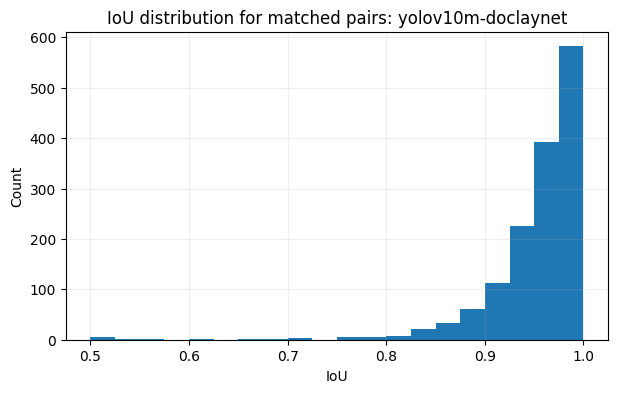

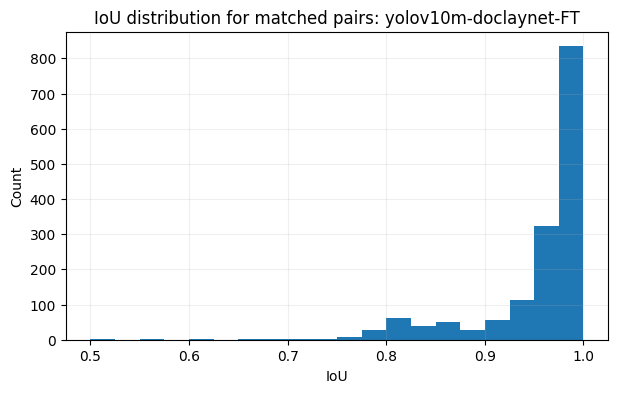

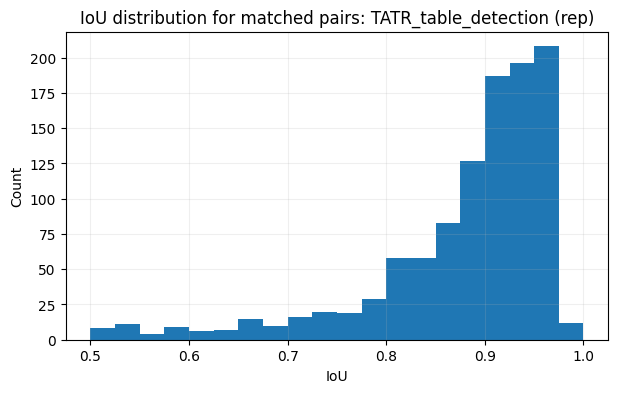

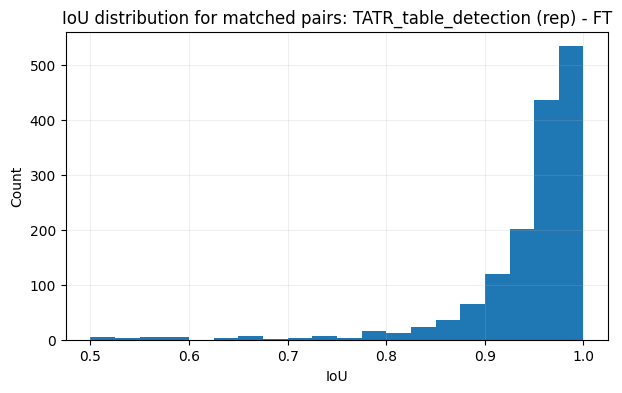

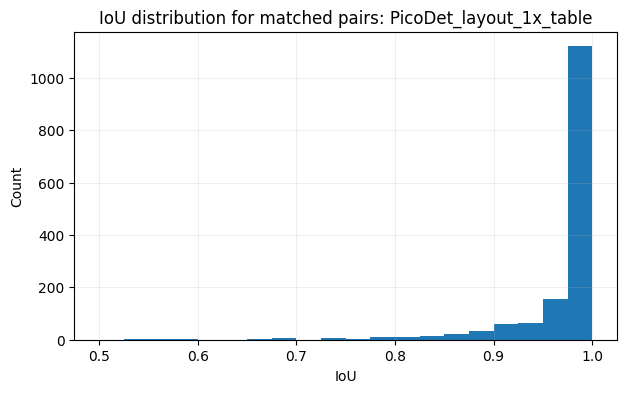

In [50]:
iou_distributions = {}

for model_name, pred_by_image in all_predictions.items():
    matched_ious = collect_matched_ious(gt_by_image, pred_by_image, match_iou_threshold=0.5)
    iou_distributions[model_name] = matched_ious

    plt.figure(figsize=(7, 4))
    plt.hist(matched_ious, bins=20, range=(0.5, 1.0))
    plt.title(f"IoU distribution for matched pairs: {model_name}")
    plt.xlabel("IoU")
    plt.ylabel("Count")
    plt.grid(alpha=0.2)
    plt.show()

In [52]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def collect_matched_ious_and_counts(
    gt_by_image: Dict[str, sv.Detections],
    pred_by_image: Dict[str, sv.Detections],
    match_iou_threshold: float = 0.5,
):
    image_ids = sorted(set(gt_by_image.keys()) | set(pred_by_image.keys()))

    all_ious = []
    total_gt_boxes = 0
    total_matched_pairs = 0

    for image_id in image_ids:
        gt_det = gt_by_image.get(image_id, empty_detections(with_confidence=False))
        pred_det = pred_by_image.get(image_id, empty_detections(with_confidence=True))

        total_gt_boxes += len(gt_det.xyxy)

        match_res = match_predictions_to_gt(
            pred_det=pred_det,
            gt_det=gt_det,
            iou_threshold=match_iou_threshold,
        )

        matched_ious = match_res["matched_ious"]
        all_ious.extend(matched_ious)
        total_matched_pairs += len(matched_ious)

    return {
        "matched_ious": np.array(all_ious, dtype=np.float32),
        "total_gt_boxes": total_gt_boxes,
        "total_matched_pairs": total_matched_pairs,
        "matched_share_of_gt": (total_matched_pairs / total_gt_boxes) if total_gt_boxes > 0 else 0.0,
    }

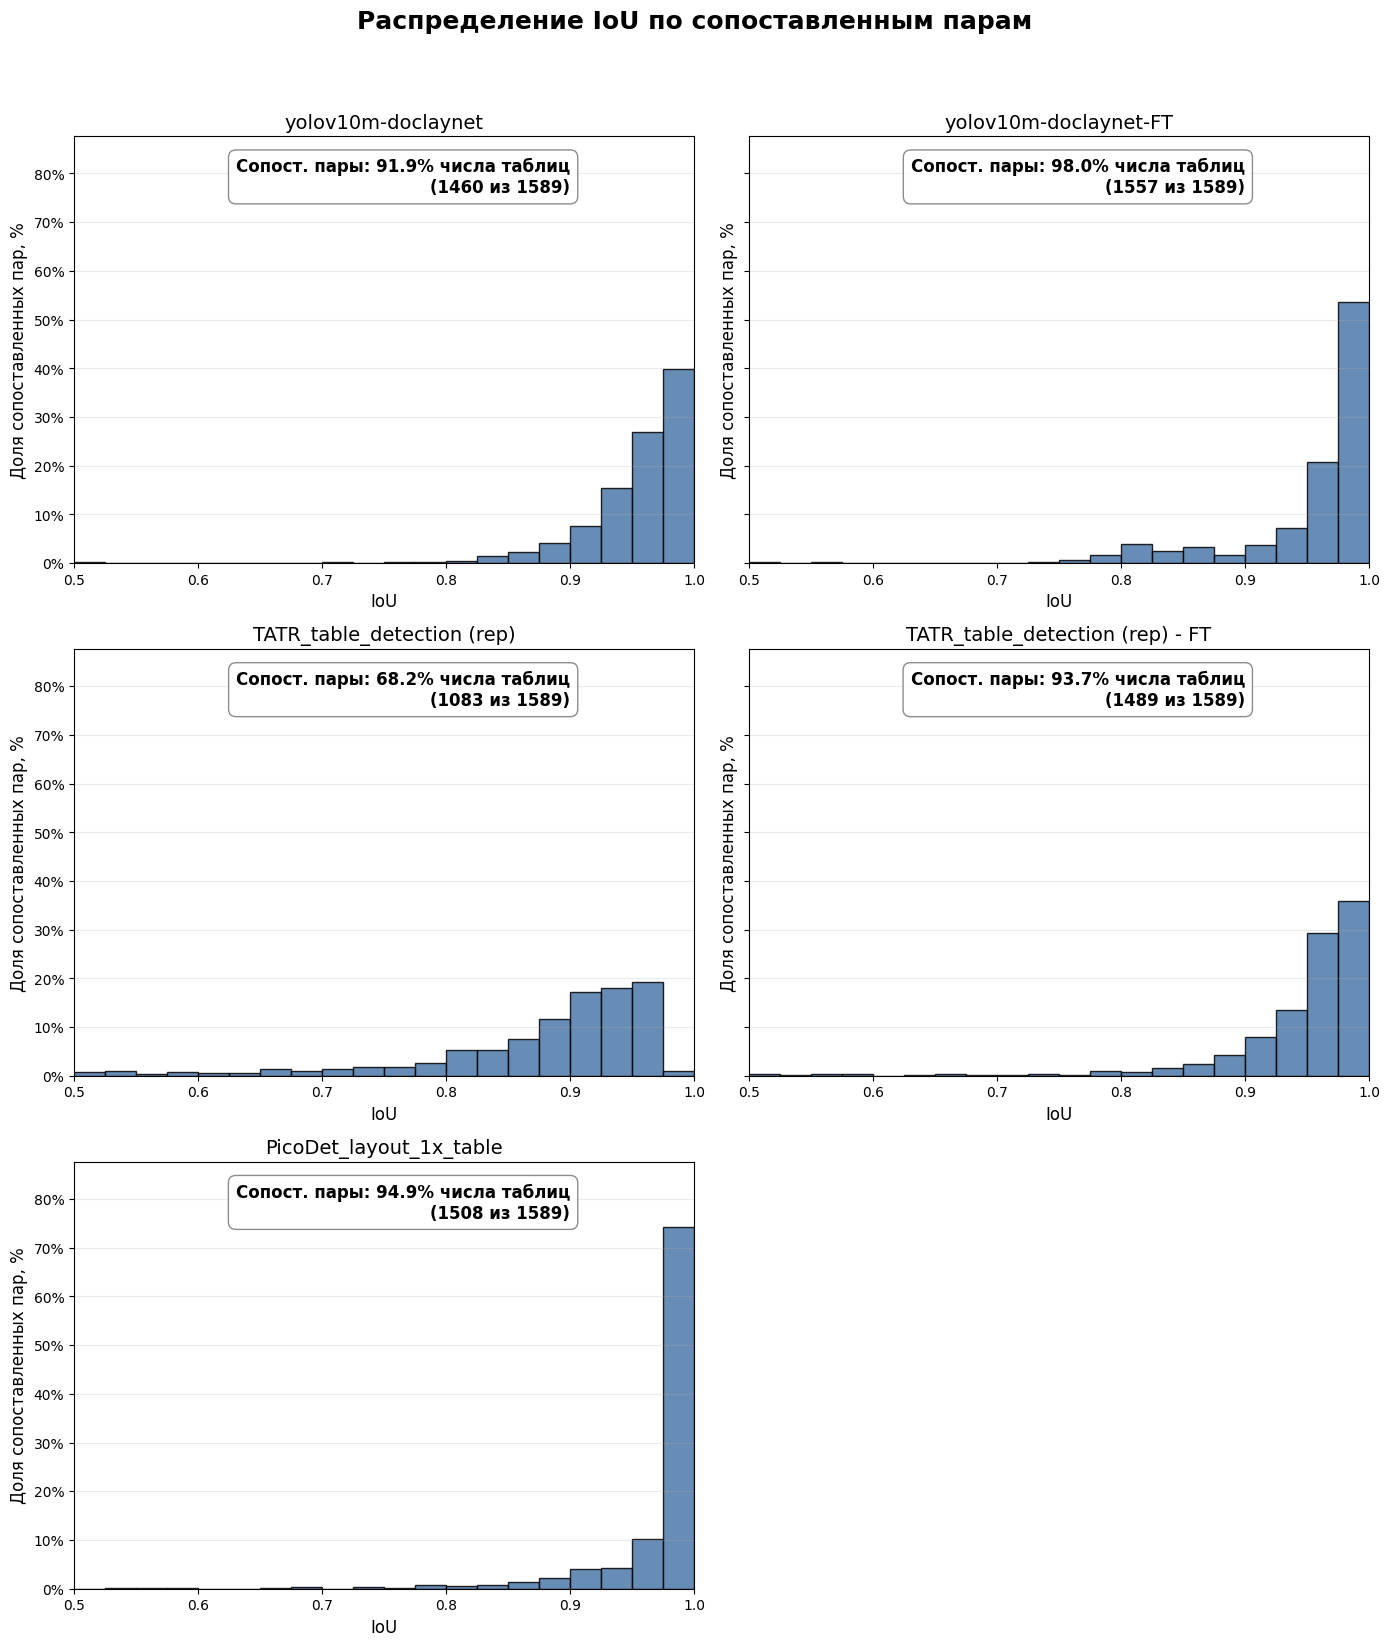

In [64]:
MATCH_IOU_THRESHOLD = 0.5
BINS = np.linspace(0.5, 1.0, 21)

model_names = list(all_predictions.keys())
#model_names = ['PicoDet_layout_1x_table',
# 'RT-DETR-H_layout_3cls',
# 'TATR_table_detection',
# 'yolov10m-doclaynet']
#  'TATR+10px',]
model_names = [
 'yolov10m-doclaynet',
  'yolov10m-doclaynet-FT',
  'TATR_table_detection (rep)',
  'TATR_table_detection (rep) - FT',
  'PicoDet_layout_1x_table']
n_models = len(model_names)

ncols = 2
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5.5 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

all_stats = {}

for model_name in model_names:
    stats = collect_matched_ious_and_counts(
        gt_by_image=gt_by_image,
        pred_by_image=all_predictions[model_name],
        match_iou_threshold=MATCH_IOU_THRESHOLD,
    )
    all_stats[model_name] = stats

max_bin_percent = 0.0
for model_name in model_names:
    matched_ious = all_stats[model_name]["matched_ious"]
    if len(matched_ious) > 0:
        weights = np.ones_like(matched_ious) * 100.0 / len(matched_ious)
        hist_vals, _ = np.histogram(matched_ious, bins=BINS, weights=weights)
        max_bin_percent = max(max_bin_percent, hist_vals.max())

for ax, model_name in zip(axes, model_names):
    stats = all_stats[model_name]
    matched_ious = stats["matched_ious"]
    total_gt_boxes = stats["total_gt_boxes"]
    total_matched_pairs = stats["total_matched_pairs"]
    matched_share_of_gt = stats["matched_share_of_gt"]

    if len(matched_ious) > 0:
        weights = np.ones_like(matched_ious) * 100.0 / len(matched_ious)
        ax.hist(
            matched_ious,
            bins=BINS,
            weights=weights,
            edgecolor="black",
            alpha=0.85,
            color="#4C78A8",
        )

    ax.set_title(model_name, fontsize=14)
    ax.set_xlim(0.5, 1.0)
    ax.set_ylim(0, max(5, max_bin_percent * 1.18))
    ax.grid(alpha=0.25, axis="y")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

    annotation_text = (
        f"Сопост. пары: {matched_share_of_gt * 100:.1f}% числа таблиц\n"
        f"({total_matched_pairs} из {total_gt_boxes})"
    )

    ax.text(
        0.8, 0.95,
        annotation_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=12,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            alpha=0.9,
            edgecolor="gray",
        ),
    )

for ax in axes[:n_models]:
    ax.set_xlabel("IoU", fontsize=12)
    ax.set_ylabel("Доля сопоставленных пар, %", fontsize=12)
    ax.set_xticks(np.arange(0.5, 1.01, 0.1))
    ax.tick_params(axis="x", labelbottom=True)

for ax in axes[n_models:]:
    ax.axis("off")

fig.suptitle(
    "Распределение IoU по сопоставленным парам",
    fontsize=18,
    fontweight="bold",
    y=0.995,
)

plt.tight_layout(rect=[0, 0, 1, 0.965])
plt.show()

## AP@0.5, AP@0.75, AP@0.9, AP@[0.5:0.95]
Supervision поддерживает MeanAveragePrecision для object detection и умеет считать COCO‑style mAP.

In [55]:
from supervision import MeanAveragePrecision

from supervision.metrics import MeanAveragePrecision
def compute_map_metrics(
    gt_by_image: Dict[str, sv.Detections],
    pred_by_image: Dict[str, sv.Detections],
):
    metric = MeanAveragePrecision()

    image_ids = sorted(set(gt_by_image.keys()) | set(pred_by_image.keys()))
    for image_id in image_ids:
        gt_det = gt_by_image.get(image_id, empty_detections(with_confidence=False))
        pred_det = pred_by_image.get(image_id, empty_detections(with_confidence=True))
        metric.update(predictions=pred_det, targets=gt_det)

    result = metric.compute()
    return result

In [56]:
map_rows = []

for model_name, pred_by_image in all_predictions.items():
    result = compute_map_metrics(gt_by_image, pred_by_image)

    map_rows.append({
        "model": model_name,
        "AP@0.5": float(result.map50),
        "AP@0.75": float(result.map75),
        "AP@[0.5:0.95]": float(result.map50_95),
    })

df_map = pd.DataFrame(map_rows).sort_values("AP@[0.5:0.95]", ascending=False)
df_map

,model,AP@0.5,AP@0.75,AP@[0.5:0.95]
1,yolov10m-doclaynet-FT,0.967343,0.965781,0.912229
4,PicoDet_layout_1x_table,0.938225,0.927093,0.906807
3,TATR_table_detection (rep) - FT,0.924880,0.901684,0.850633
0,yolov10m-doclaynet,0.906335,0.896271,0.844712
2,TATR_table_detection (rep),0.651799,0.564951,0.495507


In [58]:
import supervision as sv
print(sv.__version__)
print(dir(sv.metrics))

0.28.0
['AveragingMethod', 'F1Score', 'F1ScoreResult', 'MeanAveragePrecision', 'MeanAveragePrecisionResult', 'MeanAverageRecall', 'MeanAverageRecallResult', 'Metric', 'MetricTarget', 'ObjectSizeCategory', 'Precision', 'PrecisionResult', 'Recall', 'RecallResult', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'core', 'detection', 'f1_score', 'get_detection_size_category', 'get_object_size_category', 'mean_average_precision', 'mean_average_recall', 'precision', 'recall', 'utils']


## Средний IoU по TP при IoU ≥ 0.5

In [57]:
rows = []

for model_name, pred_by_image in all_predictions.items():
    matched_ious = collect_matched_ious(gt_by_image, pred_by_image, match_iou_threshold=0.5)
    mean_iou = float(np.mean(matched_ious)) if len(matched_ious) > 0 else 0.0

    rows.append({
        "model": model_name,
        "mean_iou_on_tp_iou>=0.5": mean_iou,
        "num_tp_pairs": len(matched_ious),
    })

df_mean_iou = pd.DataFrame(rows).sort_values("mean_iou_on_tp_iou>=0.5", ascending=False)
df_mean_iou

,model,mean_iou_on_tp_iou>=0.5,num_tp_pairs
4,PicoDet_layout_1x_table,0.972797,1508
0,yolov10m-doclaynet,0.952320,1460
1,yolov10m-doclaynet-FT,0.951599,1557
3,TATR_table_detection (rep) - FT,0.942837,1489
2,TATR_table_detection (rep),0.879270,1083


## Доли TP c IoU ≥ 0.75 и IoU ≥ 0.9

In [59]:
rows = []

for model_name, pred_by_image in all_predictions.items():
    matched_ious = collect_matched_ious(gt_by_image, pred_by_image, match_iou_threshold=0.5)
    matched_ious = np.array(matched_ious, dtype=np.float32)

    if len(matched_ious) == 0:
        share_075 = 0.0
        share_09 = 0.0
    else:
        share_075 = float((matched_ious >= 0.75).mean())
        share_09 = float((matched_ious >= 0.9).mean())

    rows.append({
        "model": model_name,
        "share_tp_iou>=0.75": share_075,
        "share_tp_iou>=0.9": share_09,
        "num_tp_pairs": len(matched_ious),
    })

df_tp_shares = pd.DataFrame(rows).sort_values("share_tp_iou>=0.75", ascending=False)
df_tp_shares

,model,share_tp_iou>=0.75,share_tp_iou>=0.9,num_tp_pairs
1,yolov10m-doclaynet-FT,0.990366,0.851638,1557
0,yolov10m-doclaynet,0.989726,0.899315,1460
4,PicoDet_layout_1x_table,0.987401,0.927056,1508
3,TATR_table_detection (rep) - FT,0.972465,0.867025,1489
2,TATR_table_detection (rep),0.902124,0.556787,1083


In [60]:
import numpy as np
import matplotlib.pyplot as plt

def box_iou_matrix(boxes1, boxes2):
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)), dtype=np.float32)

    x11, y11, x12, y12 = boxes1[:, 0][:, None], boxes1[:, 1][:, None], boxes1[:, 2][:, None], boxes1[:, 3][:, None]
    x21, y21, x22, y22 = boxes2[:, 0][None, :], boxes2[:, 1][None, :], boxes2[:, 2][None, :], boxes2[:, 3][None, :]

    inter_x1 = np.maximum(x11, x21)
    inter_y1 = np.maximum(y11, y21)
    inter_x2 = np.minimum(x12, x22)
    inter_y2 = np.minimum(y12, y22)

    inter_w = np.clip(inter_x2 - inter_x1, a_min=0, a_max=None)
    inter_h = np.clip(inter_y2 - inter_y1, a_min=0, a_max=None)
    inter = inter_w * inter_h

    area1 = np.clip(x12 - x11, 0, None) * np.clip(y12 - y11, 0, None)
    area2 = np.clip(x22 - x21, 0, None) * np.clip(y22 - y21, 0, None)
    union = area1 + area2 - inter

    return np.where(union > 0, inter / union, 0.0).astype(np.float32)


def compute_pr_curve(gt_by_image, pred_by_image, iou_threshold=0.5):
    image_ids = sorted(set(gt_by_image.keys()) | set(pred_by_image.keys()))

    total_gt = 0
    preds_all = []

    for image_id in image_ids:
        gt_det = gt_by_image.get(image_id, empty_detections(with_confidence=False))
        pred_det = pred_by_image.get(image_id, empty_detections(with_confidence=True))

        gt_boxes = gt_det.xyxy.astype(np.float32) if len(gt_det.xyxy) else np.empty((0, 4), dtype=np.float32)
        pred_boxes = pred_det.xyxy.astype(np.float32) if len(pred_det.xyxy) else np.empty((0, 4), dtype=np.float32)

        if pred_det.confidence is None:
            pred_scores = np.ones(len(pred_boxes), dtype=np.float32)
        else:
            pred_scores = pred_det.confidence.astype(np.float32)

        total_gt += len(gt_boxes)

        for box, score in zip(pred_boxes, pred_scores):
            preds_all.append({
                "image_id": image_id,
                "box": box,
                "score": float(score),
            })

    preds_all = sorted(preds_all, key=lambda x: x["score"], reverse=True)

    gt_used = {image_id: np.zeros(len(gt_by_image.get(image_id, empty_detections(with_confidence=False)).xyxy), dtype=bool)
               for image_id in image_ids}

    tp = np.zeros(len(preds_all), dtype=np.float32)
    fp = np.zeros(len(preds_all), dtype=np.float32)

    for i, pred in enumerate(preds_all):
        image_id = pred["image_id"]
        pred_box = pred["box"][None, :]

        gt_det = gt_by_image.get(image_id, empty_detections(with_confidence=False))
        gt_boxes = gt_det.xyxy.astype(np.float32) if len(gt_det.xyxy) else np.empty((0, 4), dtype=np.float32)

        if len(gt_boxes) == 0:
            fp[i] = 1
            continue

        ious = box_iou_matrix(pred_box, gt_boxes)[0]
        best_gt_idx = int(np.argmax(ious))
        best_iou = ious[best_gt_idx]

        if best_iou >= iou_threshold and not gt_used[image_id][best_gt_idx]:
            tp[i] = 1
            gt_used[image_id][best_gt_idx] = True
        else:
            fp[i] = 1

    cum_tp = np.cumsum(tp)
    cum_fp = np.cumsum(fp)

    precision = cum_tp / np.maximum(cum_tp + cum_fp, 1e-9)
    recall = cum_tp / max(total_gt, 1)

    precision = np.concatenate(([1.0], precision))
    recall = np.concatenate(([0.0], recall))

    precision_envelope = np.maximum.accumulate(precision[::-1])[::-1]
    ap = np.trapz(precision_envelope, recall)

    return recall, precision_envelope, ap


def plot_pr_curves_all_models(gt_by_image, all_predictions, iou_threshold=0.5, figsize=(8, 6)):
    plt.figure(figsize=figsize)

    rows = []
    for model_name, pred_by_image in all_predictions.items():
        recall, precision, ap = compute_pr_curve(
            gt_by_image=gt_by_image,
            pred_by_image=pred_by_image,
            iou_threshold=iou_threshold,
        )

        plt.plot(recall, precision, linewidth=2, label=f"{model_name} (AP@{iou_threshold:.2f}={ap:.3f})")
        rows.append((model_name, ap))

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall curves at IoU={iou_threshold:.2f}")
    plt.xlim(0, 1)
    plt.ylim(0, 1.02)
    plt.grid(alpha=0.25)
    plt.legend(loc="lower left")
    plt.show()

    return sorted(rows, key=lambda x: x[1], reverse=True)

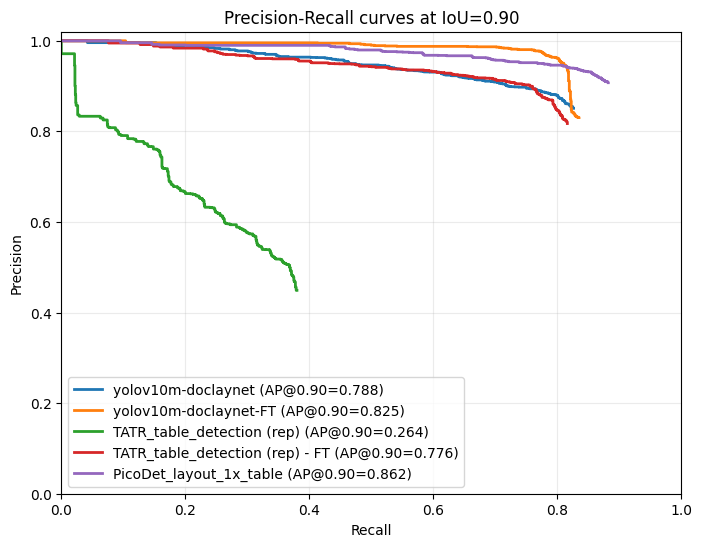

[('PicoDet_layout_1x_table', np.float64(0.8616897310602916)),
 ('yolov10m-doclaynet-FT', np.float64(0.825050686753146)),
 ('yolov10m-doclaynet', np.float64(0.787649657966162)),
 ('TATR_table_detection (rep) - FT', np.float64(0.776311559153517)),
 ('TATR_table_detection (rep)', np.float64(0.2642822369253557))]

In [61]:
pr_summary = plot_pr_curves_all_models(
    gt_by_image=gt_by_image,
    all_predictions=all_predictions,
    iou_threshold=0.9,
)
pr_summary

In [62]:
import numpy as np
import matplotlib.pyplot as plt

def box_iou_matrix(boxes1, boxes2):
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)), dtype=np.float32)

    x11, y11, x12, y12 = boxes1[:, 0][:, None], boxes1[:, 1][:, None], boxes1[:, 2][:, None], boxes1[:, 3][:, None]
    x21, y21, x22, y22 = boxes2[:, 0][None, :], boxes2[:, 1][None, :], boxes2[:, 2][None, :], boxes2[:, 3][None, :]

    inter_x1 = np.maximum(x11, x21)
    inter_y1 = np.maximum(y11, y21)
    inter_x2 = np.minimum(x12, x22)
    inter_y2 = np.minimum(y12, y22)

    inter_w = np.clip(inter_x2 - inter_x1, a_min=0, a_max=None)
    inter_h = np.clip(inter_y2 - inter_y1, a_min=0, a_max=None)
    inter = inter_w * inter_h

    area1 = np.clip(x12 - x11, 0, None) * np.clip(y12 - y11, 0, None)
    area2 = np.clip(x22 - x21, 0, None) * np.clip(y22 - y21, 0, None)
    union = area1 + area2 - inter

    return np.where(union > 0, inter / union, 0.0).astype(np.float32)


def collect_best_ious_per_gt(gt_by_image, pred_by_image):
    best_ious = []

    image_ids = sorted(set(gt_by_image.keys()) | set(pred_by_image.keys()))

    for image_id in image_ids:
        gt_det = gt_by_image.get(image_id, empty_detections(with_confidence=False))
        pred_det = pred_by_image.get(image_id, empty_detections(with_confidence=True))

        gt_boxes = gt_det.xyxy.astype(np.float32) if len(gt_det.xyxy) else np.empty((0, 4), dtype=np.float32)
        pred_boxes = pred_det.xyxy.astype(np.float32) if len(pred_det.xyxy) else np.empty((0, 4), dtype=np.float32)

        if len(gt_boxes) == 0:
            continue

        if len(pred_boxes) == 0:
            best_ious.extend([0.0] * len(gt_boxes))
            continue

        ious = box_iou_matrix(gt_boxes, pred_boxes)
        best_ious.extend(ious.max(axis=1).tolist())

    return np.array(best_ious, dtype=np.float32)


def compute_recall_vs_iou(gt_by_image, pred_by_image, iou_thresholds):
    best_ious = collect_best_ious_per_gt(gt_by_image, pred_by_image)

    if len(best_ious) == 0:
        return np.zeros(len(iou_thresholds), dtype=np.float32)

    recalls = np.array([(best_ious >= t).mean() for t in iou_thresholds], dtype=np.float32)
    return recalls


def plot_recall_vs_iou_all_models(
    gt_by_image,
    all_predictions,
    iou_thresholds=None,
    figsize=(8, 6),
):
    if iou_thresholds is None:
        iou_thresholds = np.arange(0.3, 0.96, 0.05)

    plt.figure(figsize=figsize)
    summary_rows = []

    for model_name, pred_by_image in all_predictions.items():
        recalls = compute_recall_vs_iou(
            gt_by_image=gt_by_image,
            pred_by_image=pred_by_image,
            iou_thresholds=iou_thresholds,
        )

        auc = np.trapz(recalls, iou_thresholds) / (iou_thresholds.max() - iou_thresholds.min())

        plt.plot(
            iou_thresholds,
            recalls,
            linewidth=2,
            label=f"{model_name} (AUC={auc:.3f})",
        )

        summary_rows.append({
            "model": model_name,
            "recall@0.5": float(np.interp(0.5, iou_thresholds, recalls)),
            "recall@0.75": float(np.interp(0.75, iou_thresholds, recalls)),
            "auc_recall_iou": float(auc),
        })

    plt.xlabel("Порог IoU")
    plt.ylabel("Recall")
    plt.title("Recall в зависимости от порога IoU")
    plt.xlim(float(iou_thresholds.min()), float(iou_thresholds.max()))
    plt.ylim(0, 1.02)
    plt.grid(alpha=0.25)
    plt.legend(loc="lower left")
    plt.show()

    return pd.DataFrame(summary_rows).sort_values("auc_recall_iou", ascending=False)

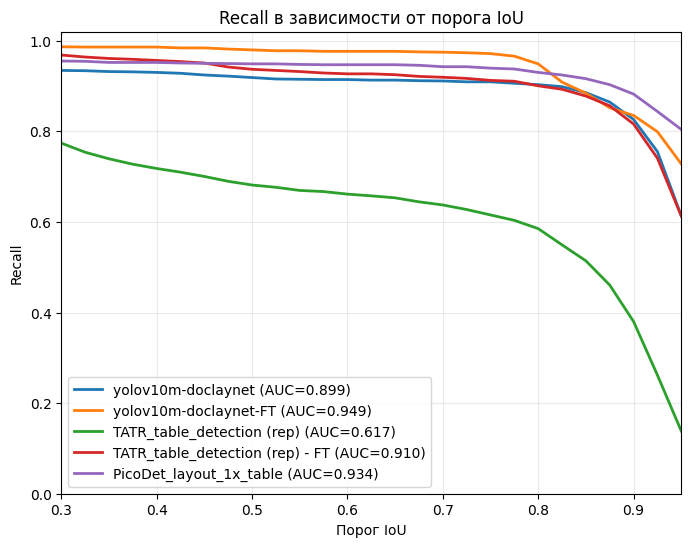

,model,recall@0.5,recall@0.75,auc_recall_iou
1,yolov10m-doclaynet-FT,0.979862,0.971680,0.949424
4,PicoDet_layout_1x_table,0.949025,0.939585,0.934042
3,TATR_table_detection (rep) - FT,0.937067,0.912524,0.909849
0,yolov10m-doclaynet,0.918817,0.909377,0.898557
2,TATR_table_detection (rep),0.681561,0.615481,0.617006


In [63]:
df_recall_iou = plot_recall_vs_iou_all_models(
    gt_by_image=gt_by_image,
    all_predictions=all_predictions,
    iou_thresholds=np.arange(0.3, 0.96, 0.025),
)

df_recall_iou

## Сводная таблица по всем моделям

In [34]:
df_prf_wide = (
    df_prf.pivot(index="model", columns="iou_threshold", values=["precision", "recall", "f1"])
    .sort_index(axis=1)
)
df_prf_wide.columns = [f"{metric}@{thr}" for metric, thr in df_prf_wide.columns]
df_prf_wide = df_prf_wide.reset_index()

df_summary = (
    df_prf_wide
    .merge(df_map, on="model", how="left")
    .merge(df_mean_iou, on="model", how="left")
    .merge(df_tp_shares, on="model", how="left", suffixes=("", "_shares"))
)

df_summary

,model,f1@0.5,f1@0.75,f1@0.9,precision@0.5,precision@0.75,precision@0.9,recall@0.5,recall@0.75,recall@0.9,AP@0.5,AP@0.75,AP@[0.5:0.95],mean_iou_on_tp_iou>=0.5,num_tp_pairs,share_tp_iou>=0.75,share_tp_iou>=0.9,num_tp_pairs_shares
0,PicoDet_layout_1x_table,0.962348,0.952776,0.894703,0.976052,0.966343,0.907443,0.949025,0.939585,0.882316,0.938225,0.927093,0.906807,0.972797,1508,0.987401,0.927056,1508
1,TATR-Repository-FT,0.937657,0.913098,0.816751,0.938248,0.913674,0.817265,0.937067,0.912524,0.816237,0.924880,0.901684,0.850633,0.942837,1489,0.972465,0.867025,1489
2,TATR-Repository-OR,0.738241,0.666667,0.411725,0.805204,0.727138,0.449071,0.681561,0.615481,0.380113,0.651799,0.564951,0.495507,0.879270,1083,0.902124,0.556787,1083
3,yolov10m-doclaynet,0.932312,0.922733,0.838442,0.946209,0.936487,0.850940,0.918817,0.909377,0.826306,0.906335,0.896271,0.844712,0.952320,1460,0.989726,0.899315,1460
4,yolov10m-doclaynet-FT,0.977094,0.968936,0.832758,0.974343,0.966208,0.830413,0.979862,0.971680,0.835116,0.967343,0.965781,0.912229,0.951599,1557,0.990366,0.851638,1557


## Визуализация предсказаний

In [39]:
def make_labels_for_detections(detections: sv.Detections, label_prefix: str) -> List[str]:
    conf = detections.confidence
    labels = []

    for i in range(len(detections.xyxy)):
        if conf is None:
            labels.append(f"{label_prefix}")
        else:
            labels.append(f"{label_prefix} {float(conf[i]):.2f}")
    return labels


def annotate_image_with_detections(
    image_np: np.ndarray,
    detections: sv.Detections,
    labels: List[str],
) -> np.ndarray:
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()

    annotated = image_np.copy()
    annotated = box_annotator.annotate(scene=annotated, detections=detections)
    annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)
    return annotated

In [35]:
from pathlib import Path
EVAL_IMAGES_DIR = Path("C://Img_Dataset/test-eval-dataset")

VALID_IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def list_image_files(images_dir: Path):
    files = [p for p in images_dir.iterdir() if p.is_file() and p.suffix.lower() in VALID_IMAGE_SUFFIXES]
    files = sorted(files, key=lambda p: p.name.lower())
    return files

IMAGE_FILES = list_image_files(EVAL_IMAGES_DIR)

print(f"Images found: {len(IMAGE_FILES)}")
print("First 10:")
for i, p in enumerate(IMAGE_FILES[:10]):
    print(i, p.name)

Images found: 989
First 10:
0 11525_1728424_p001.jpg
1 11525_1728424_p002.jpg
2 11525_1728424_p003.jpg
3 11525_1728424_p004.jpg
4 17531_1918032_p002.jpg
5 17531_1918032_p005.jpg
6 17531_1918032_p009.jpg
7 17531_1918032_p010.jpg
8 17531_1918032_p011.jpg
9 17531_1918032_p012.jpg


In [36]:
def resolve_image_path(image_ref, images_dir: Path = EVAL_IMAGES_DIR) -> Path:
    image_files = list_image_files(images_dir)

    if isinstance(image_ref, int):
        if image_ref < 0 or image_ref >= len(image_files):
            raise IndexError(f"Image index out of range: {image_ref}. Total files: {len(image_files)}")
        return image_files[image_ref]

    if isinstance(image_ref, str):
        candidate = images_dir / image_ref
        if candidate.exists():
            return candidate

        matches = [p for p in image_files if p.name == image_ref]
        if len(matches) == 1:
            return matches[0]

        raise FileNotFoundError(f"Image file not found: {image_ref}")

    raise TypeError("image_ref must be either int (index) or str (filename)")

In [37]:
def show_page_predictions(image_ref, image_key_mode: str = "stem"):
    """
    image_ref:
        - int: порядковый номер файла в директории
        - str: полное имя файла, например 'page_001.jpg'

    image_key_mode:
        - 'stem' -> ключ для gt/pred это имя файла без расширения
        - 'name' -> ключ это полное имя файла
    """
    img_path = resolve_image_path(image_ref, EVAL_IMAGES_DIR)
    image_np = np.array(Image.open(img_path).convert("RGB"))

    if image_key_mode == "stem":
        image_id = img_path.stem
    elif image_key_mode == "name":
        image_id = img_path.name
    else:
        raise ValueError("image_key_mode must be either 'stem' or 'name'")

    items_to_show = [("GT", gt_by_image.get(image_id, empty_detections(with_confidence=False)))]
    for model_name, pred_by_image in all_predictions.items():
        items_to_show.append(
            (model_name, pred_by_image.get(image_id, empty_detections(with_confidence=True)))
        )

    n = len(items_to_show)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 8))
    if n == 1:
        axes = [axes]

    for ax, (title, detections) in zip(axes, items_to_show):
        labels = make_labels_for_detections(detections, label_prefix="table")
        annotated = annotate_image_with_detections(image_np, detections, labels)

        ax.imshow(annotated)
        ax.set_title(f"{title}\n{img_path.name}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

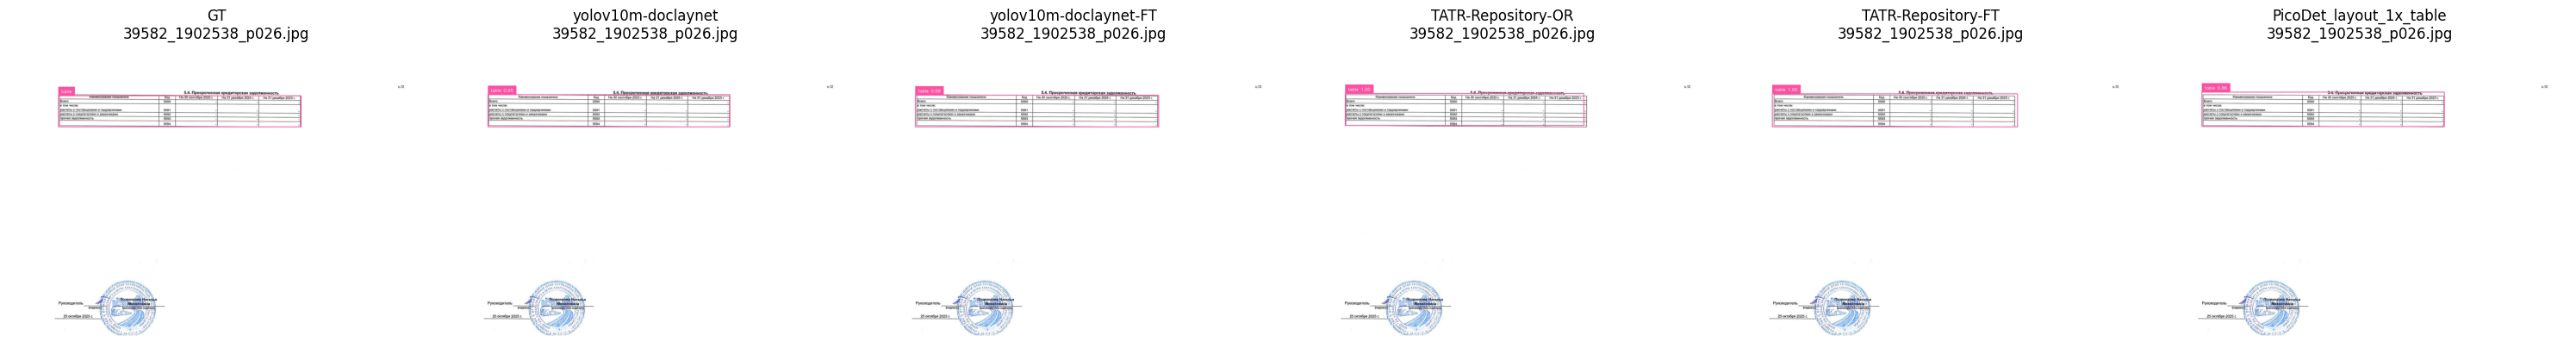

In [44]:
SELECTED_IMAGE_ID = 819

show_page_predictions(SELECTED_IMAGE_ID)

In [87]:
import numpy as np

def make_grown_predictions_from_gt_and_preds(
    gt_by_image: Dict[str, sv.Detections],
    pred_by_image: Dict[str, sv.Detections],
    margin: int = 10,
) -> Dict[str, sv.Detections]:
    grown_pred_by_image = {}

    for image_id in gt_by_image.keys():
        det = pred_by_image.get(image_id, empty_detections(with_confidence=True))

        if len(det.xyxy) == 0:
            grown_pred_by_image[image_id] = det
            continue

        xyxy = det.xyxy.copy().astype(np.float32)

        xyxy[:, 0] -= margin
        xyxy[:, 1] -= margin
        xyxy[:, 2] += margin
        xyxy[:, 3] += margin

        grown_pred_by_image[image_id] = sv.Detections(
            xyxy=xyxy,
            class_id=det.class_id.copy() if det.class_id is not None else None,
            confidence=det.confidence.copy() if det.confidence is not None else None,
            tracker_id=det.tracker_id.copy() if det.tracker_id is not None else None,
        )

    return grown_pred_by_image

In [ ]:
tatr_pred_by_image_grown = make_grown_predictions_from_gt_and_preds(
    gt_by_image,
    all_predictions["TATR_table_detection"],
    margin=10,
)

all_predictions["TATR+10px"] = tatr_pred_by_image_grown

In [98]:
del all_predictions["TATR+20px"]
del all_predictions["TATR+5px"]